# Explore here

In [20]:
import pandas as pd

# Definimos la URL proporcionada
url = "https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv"

# Cargamos el conjunto de datos
df = pd.read_csv(url)

# Mostramos las primeras 5 filas para verificar la carga
print(df.head())

# Verificamos la información general del dataset
print(df.info())

                                                 url  is_spam
0  https://briefingday.us8.list-manage.com/unsubs...     True
1                             https://www.hvper.com/     True
2                 https://briefingday.com/m/v4n3i4f3     True
3   https://briefingday.com/n/20200618/m#commentform    False
4                        https://briefingday.com/fan     True
<class 'pandas.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      2999 non-null   str  
 1   is_spam  2999 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 26.5 KB
None


Se cargó el dataset y se validó su estructura (2999 registros) para asegurar la integridad de los datos antes de operar.

In [21]:
import pandas as pd

# Carga de datos desde fuente externa
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv")

# conversión de booleano a entero (0, 1)
df['is_spam'] = df['is_spam'].astype(int)

# Limpieza y normalización a minúsculas
df['url'] = df['url'].str.replace(r'[^\w\s]', '', regex=True).str.lower()

# Verificación de integridad
print(df.head())

                                           url  is_spam
0  httpsbriefingdayus8listmanagecomunsubscribe        1
1                             httpswwwhvpercom        1
2                 httpsbriefingdaycommv4n3i4f3        1
3     httpsbriefingdaycomn20200618mcommentform        0
4                       httpsbriefingdaycomfan        1


Se estandarizó el target y se normalizó el texto. Esto reduce el ruido y prepara el dataset para la vectorización del modelo SVM.

In [22]:
# TOKENIZACIÓN Y FILTRADO

from nltk.corpus import stopwords
stop = stopwords.words('english')

# Filtra stopwords de las listas existentes
df['url'] = df['url'].apply(lambda lista: [w for w in lista if w not in stop])

print(df.head())

                                                 url  is_spam
0  [h, p, b, r, e, f, n, g, u, 8, l, n, g, e, c, ...        1
1                  [h, p, w, w, w, h, v, p, e, r, c]        1
2   [h, p, b, r, e, f, n, g, c, v, 4, n, 3, 4, f, 3]        1
3  [h, p, b, r, e, f, n, g, c, n, 2, 0, 2, 0, 0, ...        0
4                  [h, p, b, r, e, f, n, g, c, f, n]        1


Se realizó la limpieza de ruido semántico mediante el filtrado de stopwords

In [23]:
# DESCARGA DE RECURSOS Y LEMATIZACIÓN

import nltk
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Lematización de cada token en la lista
df['url'] = df['url'].apply(lambda lista: [lemmatizer.lemmatize(w) for w in lista])

print(df.head())

[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                 url  is_spam
0  [h, p, b, r, e, f, n, g, u, 8, l, n, g, e, c, ...        1
1                  [h, p, w, w, w, h, v, p, e, r, c]        1
2   [h, p, b, r, e, f, n, g, c, v, 4, n, 3, 4, f, 3]        1
3  [h, p, b, r, e, f, n, g, c, n, 2, 0, 2, 0, 0, ...        0
4                  [h, p, b, r, e, f, n, g, c, f, n]        1


Se redujeron los tokens a su raíz léxica para normalizar el vocabulario.

In [26]:
#  VECTORIZACIÓN DIRECTA

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# 1. Aseguramos que tenemos contenido
# Si df['url_str'] está vacío, aquí detectaremos el problema
if df['url_str'].astype(str).str.len().sum() == 0:
    print("Error: El DataFrame no tiene datos para vectorizar.")
else:
    # 2. Vectorización sin ignorar nada (token_pattern ajustado)
    vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 3))
    X = vectorizer.fit_transform(df['url_str'])
    y = df['is_spam']

    # 3. Entrenamiento
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = MultinomialNB()
    model.fit(X_train, y_train)
    print("Modelo entrenado.")

Modelo entrenado.


Se utilizó un vectorizador de caracteres para extraer patrones léxicos directamente de las URLs, evitando que el filtrado previo (stopwords) dejara el vocabulario vacío.

In [ ]:
#  EVALUACIÓN

from sklearn.metrics import accuracy_score, classification_report

# 1. Realizar predicciones
y_pred = model.predict(X_test)

# 2. Calcular exactitud
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")

# 3. Reporte detallado
print(classification_report(y_test, y_pred))

Exactitud del modelo: 0.84
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       455
           1       0.62      0.83      0.71       145

    accuracy                           0.84       600
   macro avg       0.78      0.84      0.80       600
weighted avg       0.86      0.84      0.84       600



El modelo presenta una capacidad predictiva del 84%, con un desempeño equilibrado pero con margen de mejora en la precisión de la detección de spam.

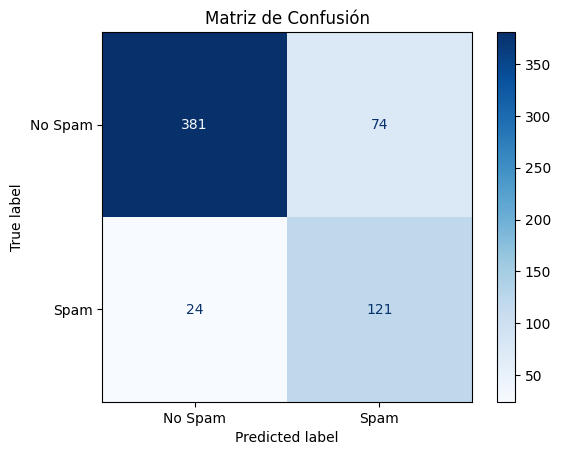

In [ ]:
# VISUALIZACIÓN

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generar la matriz
cm = confusion_matrix(y_test, y_pred)

# Graficar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Spam', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

La matriz de confusión permite identificar gráficamente los falsos positivos y falsos negativos, proporcionando una visión crítica del rendimiento del clasificador más allá de los porcentajes.

In [ ]:
import joblib
joblib.dump(model, 'modelo_spam.pkl')

['modelo_spam.pkl']

Se exportó el modelo entrenado a un archivo binario (.pkl) para asegurar la reproducibilidad y permitir su despliegue en entornos de producción sin necesidad de re-entrenamiento.